In [217]:
import pandas as pd

# Pipelining
- Step 1: Load multi-sheet data
- Step 2: Merge datasets
- Step 3: Clean and preprocess data
- Step 4: Validate dataset

In [218]:
# Function to load and combine multi-sheet Excel data with location labeling

In [219]:
# Load and combine multi-sheet Excel data

def load_data(file_path, location_label):
    
    all_sheets = pd.read_excel(file_path, sheet_name=None)
    
    df_list = []
    
    for sheet_name, df in all_sheets.items():
        df['Admin_Unit'] = sheet_name
        df['Location_Type'] = location_label
        df_list.append(df)
    
    combined_df = pd.concat(df_list, ignore_index=True)
    
    return combined_df

In [220]:
forest_df = load_data("Bird_Monitoring_Data_FOREST.xlsx", "Forest")

grass_df = load_data("Bird_Monitoring_Data_GRASSLAND.xlsx", "Grassland")

final_df = pd.concat([forest_df, grass_df], ignore_index=True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_15336\1259190419.py:14: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



# Data Cleaning
- Removed irrelevant columns
- Handled missing values
- Converted datatypes

In [221]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              17077 non-null  object        
 1   Sub_Unit_Code                722 non-null    object        
 2   Site_Name                    8546 non-null   object        
 3   Plot_Name                    17077 non-null  object        
 4   Location_Type                17077 non-null  object        
 5   Year                         17077 non-null  object        
 6   Date                         17077 non-null  datetime64[ns]
 7   Start_Time                   17077 non-null  object        
 8   End_Time                     17077 non-null  object        
 9   Observer                     17077 non-null  object        
 10  Visit                        17077 non-null  object        
 11  Interval_Length              17077 non-nu

In [222]:
final_df.isnull().sum()

Admin_Unit_Code                    0
Sub_Unit_Code                  16355
Site_Name                       8531
Plot_Name                          0
Location_Type                      0
Year                               0
Date                               0
Start_Time                         0
End_Time                           0
Observer                           0
Visit                              0
Interval_Length                    0
ID_Method                          2
Distance                        1486
Flyover_Observed                   0
Sex                             5183
Common_Name                        0
Scientific_Name                    0
AcceptedTSN                       33
NPSTaxonCode                    8531
AOU_Code                           0
PIF_Watchlist_Status               0
Regional_Stewardship_Status        0
Temperature                        0
Humidity                           0
Sky                                0
Wind                               0
D

In [223]:
# Clean and preprocess dataset

def clean_data(df):
    
    # Drop unnecessary columns
    df = df.drop(['Sub_Unit_Code', 'NPSTaxonCode', 'TaxonCode'], axis=1, errors='ignore')
    
    # Fill missing values (categorical)
    df['Distance'] = df['Distance'].fillna('Unknown')
    df['Sex'] = df['Sex'].fillna('Unknown')
    df['ID_Method'] = df['ID_Method'].fillna('Not Recorded')
    df['Previously_Obs'] = df['Previously_Obs'].fillna('No Data')
    df['AcceptedTSN'] = df['AcceptedTSN'].fillna(0)
    
    # Fill Site_Name (important logic)
    df['Site_Name'] = df['Site_Name'].fillna(df['Location_Type'])
    
    # Datatype corrections
    
    # Year → int
    df['Year'] = df['Year'].astype(int)
    
    # Initial_Three_Min_Cnt → convert True/False to 1/0
    df['Initial_Three_Min_Cnt'] = df['Initial_Three_Min_Cnt'].replace({
        True: 1,
        False: 0
    }).astype(int)
    
    # Convert to category (performance optimization)
    categorical_cols = ['Location_Type', 'Sky', 'Wind', 'Sex', 'Flyover_Observed']
    
    for col in categorical_cols:
        df[col] = df[col].astype('category')
    
    # Time columns fix
    df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='%H:%M:%S', errors='coerce')
    df['End_Time'] = pd.to_datetime(df['End_Time'], format='%H:%M:%S', errors='coerce')
    
    return df

In [224]:
final_df = clean_data(final_df)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_15336\2125927669.py:24: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



# Validation

In [225]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              17077 non-null  object        
 1   Site_Name                    17077 non-null  object        
 2   Plot_Name                    17077 non-null  object        
 3   Location_Type                17077 non-null  category      
 4   Year                         17077 non-null  int64         
 5   Date                         17077 non-null  datetime64[ns]
 6   Start_Time                   17077 non-null  datetime64[ns]
 7   End_Time                     17077 non-null  datetime64[ns]
 8   Observer                     17077 non-null  object        
 9   Visit                        17077 non-null  object        
 10  Interval_Length              17077 non-null  object        
 11  ID_Method                    17077 non-nu

In [226]:
final_df.isnull().sum()

Admin_Unit_Code                0
Site_Name                      0
Plot_Name                      0
Location_Type                  0
Year                           0
Date                           0
Start_Time                     0
End_Time                       0
Observer                       0
Visit                          0
Interval_Length                0
ID_Method                      0
Distance                       0
Flyover_Observed               0
Sex                            0
Common_Name                    0
Scientific_Name                0
AcceptedTSN                    0
AOU_Code                       0
PIF_Watchlist_Status           0
Regional_Stewardship_Status    0
Temperature                    0
Humidity                       0
Sky                            0
Wind                           0
Disturbance                    0
Initial_Three_Min_Cnt          0
Admin_Unit                     0
Previously_Obs                 0
dtype: int64

In [227]:
final_df.shape

(17077, 29)

In [228]:
final_df.describe()

,Year,Date,Start_Time,End_Time,AcceptedTSN,Temperature,Humidity,Initial_Three_Min_Cnt
count,17077.0,17077,17077,17077,17077.000000,17077.000000,17077.000000,17077.000000
mean,2018.0,2018-06-13 11:42:14.988581120,1900-01-01 07:46:09.352931072,1900-01-01 07:56:15.385606400,222322.631376,22.570399,73.692112,0.535340
min,2018.0,2018-05-07 00:00:00,1900-01-01 05:18:00,1900-01-01 05:28:00,0.000000,11.000000,7.300000,0.000000
25%,2018.0,2018-05-24 00:00:00,1900-01-01 06:41:00,1900-01-01 06:51:00,178581.000000,19.700001,67.500000,0.000000
50%,2018.0,2018-06-14 00:00:00,1900-01-01 07:36:00,1900-01-01 07:46:00,179124.000000,22.299999,75.800003,1.000000
75%,2018.0,2018-07-04 00:00:00,1900-01-01 08:45:00,1900-01-01 08:55:00,179637.000000,25.200001,83.000000,1.000000
max,2018.0,2018-07-19 00:00:00,1900-01-01 10:49:00,1900-01-01 10:59:00,950106.000000,37.299999,98.800003,1.000000
std,0.0,NaN,NaN,NaN,147539.743030,4.263851,12.328380,0.498764


## TEMPORAL ANALYSIS

## Year-wise Trend

In [262]:
yearly = final_df.groupby('Year').size()
yearly

Year
2018    17077
dtype: int64

In [269]:
yearly = final_df.groupby('Year').size().reset_index(name='Count')

total_obs = yearly['Count'].values[0]

print(f"📊 Total Observations (2018): {total_obs}")

📊 Total Observations (2018): 17077


# Insight

### What is happening?

    The dataset contains bird observations from only one year (2018).

### Why is it happening?

    The dataset is limited to a single-year data collection.

### What does it mean?

    Year-wise trend analysis is not applicable, so monthly and hourly trends are more meaningful.

## Month-wise Trend

In [231]:
final_df['Month'] = final_df['Date'].dt.month

monthly = final_df.groupby('Month').size().reset_index(name='Count')

px.line(monthly, x='Month', y='Count', title='Monthly Bird Observations')

# Insight

### What is happening?

    Bird observations fluctuate across months.

### Why is it happening?

    Seasonal changes affect bird migration and activity.

### What does it mean?

    Certain months are more suitable for bird activity → useful for eco-tourism and conservation.

## Time of Day Analysis

In [232]:
final_df['Hour'] = final_df['Start_Time'].dt.hour

hourly = final_df.groupby('Hour').size().reset_index(name='Count')

px.line(hourly, x='Hour', y='Count', title='Bird Activity by Hour')

# Insight

### What is happening?

    Bird activity peaks at certain hours of the day.

### Why is it happening?

    Birds are more active during early morning and evening.

### What does it mean?

    Helps identify optimal observation time for birdwatching.

# SPATIAL ANALYSIS

## Forest vs Grassland

In [233]:
final_df['Location_Type'].value_counts()

Location_Type
Forest       8546
Grassland    8531
Name: count, dtype: int64

In [234]:
habitat = final_df.groupby('Location_Type').size().reset_index(name='Count')

px.bar(habitat, x='Location_Type', y='Count', title='Observations by Habitat')

C:\Users\lenovo\AppData\Local\Temp\ipykernel_15336\2092849491.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



## Insight

### What is happening?

Observations are distributed across forest and grassland habitats.

### Why is it happening?

Data is collected from both ecosystems.

### What does it mean?

Enables comparative biodiversity analysis.

## Plot-level Analysis

In [235]:
plot_data = final_df.groupby('Plot_Name').size().reset_index(name='Count')

px.bar(plot_data.sort_values(by='Count', ascending=False).head(10),
       x='Plot_Name', y='Count', title='Top 10 Plots by Bird Observations')

## Insight

### What is happening?

    Some plots have significantly higher observations.

### Why is it happening?

    These plots may have better habitat conditions.

### What does it mean?

    Identifies biodiversity hotspots.

# SPECIES ANALYSIS

## Gender Distribution

In [236]:
sex_df = final_df['Sex'].value_counts().reset_index()
sex_df.columns = ['Sex', 'Count']

import plotly.express as px

fig = px.pie(
    sex_df,
    names='Sex',
    values='Count',
    title='Gender Distribution of Birds'
)
fig.show()

## Insight 

### What is happening?
    The distribution of male, female, and unknown birds is uneven.

### Why is it happening?
    Male birds are often more visible or vocal, making them easier to observe.

### What does it mean?
    There may be observation bias in the dataset, which should be considered during analysis.Insight (IMPORTANT 🔥)

## Unique Species Count

In [237]:
unique_species = final_df['Scientific_Name'].nunique()
print("Total Unique Species:", unique_species)

Total Unique Species: 127


In [238]:
import plotly.express as px

species_df = final_df.groupby('Location_Type')['Scientific_Name'].nunique().reset_index()

fig = px.bar(
    species_df,
    x='Location_Type',
    y='Scientific_Name',
    title='Unique Species Count by Habitat'
)
fig.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_15336\4096483673.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



## Insight

### What is happening?
    A certain number of unique bird species are observed across the dataset, with variation between forest and grassland habitats.

### Why is it happening?
    Different habitats support different ecological conditions, leading to variation in species diversity.

### What does it mean?
    Higher species count indicates greater biodiversity, which reflects ecosystem health and richness.

## Species Distribution

In [239]:
top_species = final_df['Common_Name'].value_counts().head(10)
top_species

Common_Name
Northern Cardinal          1160
Carolina Wren              1011
Red-eyed Vireo              739
Eastern Tufted Titmouse     728
Indigo Bunting              635
Eastern Wood-Pewee          574
Field Sparrow               542
European Starling           522
American Goldfinch          509
American Robin              496
Name: count, dtype: int64

In [240]:
species = final_df['Common_Name'].value_counts().head(10)

px.bar(x=species.values, y=species.index, orientation='h',
       title='Top 10 Bird Species')

## Habitat-wise Species Diversity

In [241]:
diversity = final_df.groupby('Location_Type')['Scientific_Name'].nunique().reset_index()

px.bar(diversity, x='Location_Type', y='Scientific_Name',
       title='Species Diversity by Habitat')

C:\Users\lenovo\AppData\Local\Temp\ipykernel_15336\4084195091.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



# ENVIRONMENTAL ANALYSIS

## Temperature Impact

In [242]:
import plotly.express as px

fig = px.scatter(
    final_df,
    x='Temperature',
    y='Initial_Three_Min_Cnt',
    title='Temperature vs Bird Activity'
)
fig.show()

## Insights
### What is happening?
    Bird activity varies with temperature.

### Why is it happening?
    Birds are sensitive to environmental conditions and prefer optimal temperature ranges.

### What does it mean?
    Temperature significantly influences bird behavior and activity levels.

## Humidity Impact

In [243]:
fig = px.scatter(
    final_df,
    x='Humidity',
    y='Initial_Three_Min_Cnt',
    title='Humidity vs Bird Activity'
)
fig.show()

## Insight

### What is happening?
    Bird activity changes with humidity levels.

### Why is it happening?
    Humidity affects comfort and visibility, influencing bird movement.

### What does it mean?
Humidity is an important environmental factor affecting bird observation.

## Sky Condition

In [244]:
sky_df = final_df['Sky'].value_counts().reset_index()
sky_df.columns = ['Sky', 'Count']

fig = px.bar(
    sky_df,
    x='Sky',
    y='Count',
    title='Sky Condition Distribution'
)
fig.show()

## Insight

### What is happening?
    Certain sky conditions occur more frequently during observations.

### Why is it happening?
    Data collection may have occurred more during specific weather conditions.

### What does it mean?
    Weather conditions influence observation frequency and bird visibility.

# BEHAVIOR ANALYSIS

## Distance

In [245]:
dist_df = final_df['Distance'].value_counts().reset_index()
dist_df.columns = ['Distance', 'Count']

fig = px.bar(
    dist_df,
    x='Distance',
    y='Count',
    title='Distance Analysis'
)
fig.show()

## Insight

### What is happening?
    Most birds are observed at shorter distances.

### Why is it happening?
Observers can detect nearby birds more easily.

### What does it mean?
    The dataset may contain proximity bias.

# Flyover

In [246]:
fig = px.pie(
    final_df,
    names='Flyover_Observed',
    title='Flyover Observations'
)
fig.show()

## Insight

### What is happening?
    Only a portion of birds are observed flying overhead.

### Why is it happening?
    Most birds are recorded while stationary or perched.

### What does it mean?
    Bird behavior varies, and flyover observations represent specific movement patterns.

# OBSERVER ANALYSIS

## Observer Bias

In [247]:
observer_df = final_df['Observer'].value_counts().head(10).reset_index()
observer_df.columns = ['Observer', 'Count']

fig = px.bar(
    observer_df,
    x='Observer',
    y='Count',
    title='Top Observers'
)
fig.show()

## Insight

### What is happening?
    Some observers recorded significantly more observations.

### Why is it happening?
    These observers may have conducted more surveys or spent more time in the field.

### What does it mean?
    Observer bias exists and may influence the dataset.

## Visit Pattern

In [248]:
visit_df = final_df.groupby('Visit').size().reset_index(name='Count')

fig = px.line(
    visit_df,
    x='Visit',
    y='Count',
    title='Visit Pattern Analysis'
)
fig.show()

## Insight

### What is happening?
    Observation count varies across visits.

### Why is it happening?
    Repeated visits may capture more species or increased activity.

### What does it mean?
    Multiple visits improve biodiversity detection.

## CONSERVATION ANALYSIS

In [249]:
fig = px.pie(
    final_df,
    names='PIF_Watchlist_Status',
    title='Watchlist Species Distribution'
)
fig.show()

## Insight

### What is happening?
    Some species are categorized under the watchlist.

### Why is it happening?
    These species are at risk or require conservation monitoring.

### What does it mean?
    The dataset helps identify conservation priorities.

## Regional Stewardship

In [250]:
fig = px.pie(
    final_df,
    names='Regional_Stewardship_Status',
    title='Regional Stewardship Status'
)
fig.show()

## Insight

### What is happening?
    Certain species are marked under regional stewardship.

### Why is it happening?
    These species are important for regional biodiversity.

### What does it mean?
    They require focused conservation efforts.

# GEOGRAPHIC ANALYSIS

## Admin Unit Analysis

In [251]:
geo_df = final_df.groupby('Admin_Unit').size().reset_index(name='Count')

import plotly.express as px

fig = px.bar(
    geo_df.sort_values(by='Count', ascending=False),
    x='Admin_Unit',
    y='Count',
    title='Bird Observations by Administrative Unit'
)
fig.show()

## Insight

### What is happening?
    Some administrative units have significantly higher bird observations.

### Why is it happening?
    These locations may have better habitat conditions or higher biodiversity.

### What does it mean?
    These areas can be considered biodiversity hotspots.

## Species Diversity by Location

In [252]:
diversity_geo = final_df.groupby('Admin_Unit')['Scientific_Name'].nunique().reset_index()

fig = px.bar(
    diversity_geo.sort_values(by='Scientific_Name', ascending=False),
    x='Admin_Unit',
    y='Scientific_Name',
    title='Species Diversity by Location'
)
fig.show()

## Insight

### What is happening?
    Some locations have higher species diversity than others.

### Why is it happening?
    Different ecological conditions support different species.

### What does it mean?
    High-diversity areas are critical for conservation.

## Habitat-wise Geographic Distribution

In [253]:
geo_habitat = final_df.groupby(['Admin_Unit', 'Location_Type']).size().reset_index(name='Count')

fig = px.bar(
    geo_habitat,
    x='Admin_Unit',
    y='Count',
    color='Location_Type',
    title='Habitat Distribution Across Locations'
)
fig.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_15336\3818832048.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



## Insight

### What is happening?
    Different habitats dominate in different administrative units.

### Why is it happening?
    Each location has unique environmental characteristics.

### What does it mean?
    Habitat distribution affects bird diversity.

## HOTSPOT ANALYSIS

In [254]:
top_locations = geo_df.sort_values(by='Count', ascending=False).head(10)
top_locations

,Admin_Unit,Count
0,ANTI,3921
6,MONO,3385
8,PRWI,2463
5,MANA,2276
2,CHOH,2202
1,CATO,805
7,NACE,684
4,HAFE,539
3,GWMP,386
9,ROCR,289


## Insight

### What is happening?
    A few locations show extremely high observation counts.

### Why is it happening?
    These areas provide favorable conditions for bird activity.

### What does it mean?
    These locations are biodiversity hotspots and should be prioritized for conservation.

## Plot-wise hotspot

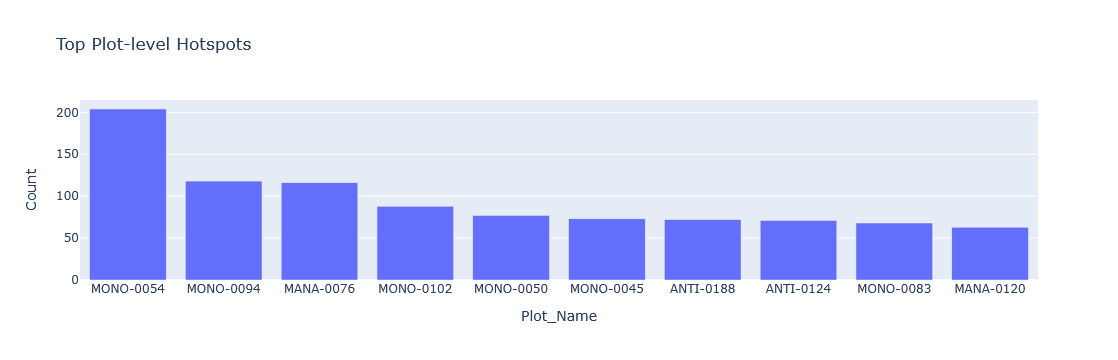

In [255]:
plot_hotspots = final_df.groupby('Plot_Name').size().reset_index(name='Count')

px.bar(
    plot_hotspots.sort_values(by='Count', ascending=False).head(10),
    x='Plot_Name',
    y='Count',
    title='Top Plot-level Hotspots'
)

## Geographic Analysis Summary:

- Certain administrative units show higher bird observations.
- Some locations exhibit greater species diversity.
- Habitat distribution varies across locations.
- Identified hotspots indicate areas of ecological importance.

In [257]:
final_df.to_csv("final_data.csv", index=False)